# Simulazione di Gestione Crisi Idrica
## Integrazione Dominio Idrico e Sensoristico

Questo progetto unisce:
- **Dyn-WNTR**: per la simulazione della rete idrica
- **LoRaSim**: per la simulazione della rete di sensori LoRaWAN

**Obiettivo**: Gestire una crisi idrica attraverso serbatoi intelligenti controllati da un agente centrale.

## 1. Import delle Librerie e Configurazione Ambiente

In [29]:
!git clone https://github.com/rastafaninplakeibol/Dyn-WNTR.git

fatal: destination path 'Dyn-WNTR' already exists and is not an empty directory.


In [30]:
!git clone https://github.com/mcbor/lorasim.git

fatal: destination path 'lorasim' already exists and is not an empty directory.


In [ ]:
!pip install simpy 

In [32]:
import os
import sys
import subprocess
import numpy as np
import importlib

# --- 1. CONFIGURAZIONE PERCORSI ---
root_dir = "/content/Dyn-WNTR"
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

print("🔧 Inizio configurazione Dyn-WNTR...")

# Funzione helper per compilare moduli C++
def compile_module(source_cpp, source_wrap, output_so, include_dirs):
    try:
        py_include = "/usr/include/python3.12" # Potrebbe variare, proviamo prima questo o lo ricaviamo
        import sysconfig
        py_include = sysconfig.get_path('include')

        np_include = np.get_include()

        includes = [f"-I {d}" for d in include_dirs] + [f"-I {py_include}", f"-I {np_include}"]
        include_flags = " ".join(includes)

        print(f"   Compilazione {os.path.basename(output_so)}...")

        # Step 1: Compila logica C++
        subprocess.check_call([
            "g++", "-O3", "-fPIC", "-std=c++11", "-c", source_cpp,
            "-o", "temp_obj.o", "-I", os.path.dirname(source_cpp)
        ])

        # Step 2: Compila Wrapper SWIG
        subprocess.check_call([
            "g++", "-O3", "-fPIC", "-std=c++11", "-c", source_wrap,
            "-o", "temp_wrap.o", "-I", os.path.dirname(source_wrap),
            "-I", py_include, "-I", np_include
        ])

        # Step 3: Linking
        subprocess.check_call([
            "g++", "-shared", "-fPIC", "temp_obj.o", "temp_wrap.o",
            "-o", output_so
        ])

        # Pulizia temporanei
        if os.path.exists("temp_obj.o"): os.remove("temp_obj.o")
        if os.path.exists("temp_wrap.o"): os.remove("temp_wrap.o")

        return True
    except Exception as e:
        print(f"   ❌ Errore compilazione: {e}")
        return False

# --- 2. COMPILAZIONE NETWORK ISOLATION ---
iso_dir = os.path.join(root_dir, "mwntr/sim/network_isolation")
source_cpp_iso = os.path.join(iso_dir, "network_isolation.cpp")
source_wrap_iso = os.path.join(iso_dir, "network_isolation_wrap.cpp")
output_so_iso = os.path.join(iso_dir, "_network_isolation.so")

if os.path.exists(source_cpp_iso):
    compile_module(source_cpp_iso, source_wrap_iso, output_so_iso, [iso_dir])
else:
    print("⚠️ File network_isolation.cpp non trovato.")

# --- 3. COMPILAZIONE AML EVALUATOR (IL PEZZO MANCANTE) ---
aml_dir = os.path.join(root_dir, "mwntr/sim/aml")
source_cpp_aml = os.path.join(aml_dir, "evaluator.cpp")
source_wrap_aml = os.path.join(aml_dir, "evaluator_wrap.cpp")
output_so_aml = os.path.join(aml_dir, "_evaluator.so")

if os.path.exists(source_cpp_aml):
    compile_module(source_cpp_aml, source_wrap_aml, output_so_aml, [aml_dir])
else:
    print(f"⚠️ File evaluator.cpp non trovato in {aml_dir}. Verifica la struttura del repo.")

# --- 4. PATCH HYDRAULICS.PY ---
path_to_fix = os.path.join(root_dir, 'mwntr/sim/hydraulics.py')
if os.path.exists(path_to_fix):
    print("   Applicazione patch hydraulics.py...")
    with open(path_to_fix, 'r') as f:
        lines = f.readlines()

    new_lines = []
    skip_next = False
    for i, line in enumerate(lines):
        if skip_next:
            skip_next = False
            continue

        # Cerchiamo la riga problematica
        if "node_res[key] = pd.DataFrame(data=np.array([node_res[key][name] for name in node_names]).transpose(), index=results.time," in line:
            indent = line[:len(line) - len(line.lstrip())]
            patch = [
                f"{indent}try:\n",
                f"{indent}    _data = np.array([node_res[key][name] for name in node_names]).transpose()\n",
                f"{indent}    if _data.size == 0:\n",
                f"{indent}        node_res[key] = pd.DataFrame()\n",
                f"{indent}    else:\n",
                f"{indent}        node_res[key] = pd.DataFrame(data=_data, index=results.time, columns=node_names)\n",
                f"{indent}except Exception:\n",
                f"{indent}    node_res[key] = pd.DataFrame()\n"
            ]
            new_lines.extend(patch)
        elif "columns=node_names)" in line and "pd.DataFrame" not in line and "node_res[key]" not in line:
            # Saltiamo la continuazione della riga precedente se esiste
            continue
        else:
            new_lines.append(line)

    with open(path_to_fix, 'w') as f:
        f.writelines(new_lines)
    print("   ✅ Patch hydraulics.py applicata.")
else:
    print("⚠️ File hydraulics.py non trovato per la patch.")

# --- 5. VERIFICA IMPORT ---
print("\n🚀 Tentativo di import finale...")
try:
    # Forza il ricaricamento se già parzialmente importato
    if 'mwntr' in sys.modules:
        del sys.modules['mwntr']
    if 'mwntr.sim.aml' in sys.modules:
        del sys.modules['mwntr.sim.aml']

    import mwntr
    import mwntr.sim.network_isolation._network_isolation as ni
    import mwntr.sim.aml._evaluator as ev

    print("\n✅ SUCCESSO! TUTTI I MODULI SONO PRONTI!")
    print(f"   - Network Isolation: OK")
    print(f"   - AML Evaluator: OK")
    print(f"   - Hydraulics Patch: OK")
    print("Dyn-WNTR è completamente configurato.")

except Exception as e:
    print(f"\n❌ ERRORE PERSISTENTE: {e}")
    import traceback
    traceback.print_exc()

🔧 Inizio configurazione Dyn-WNTR...
   Compilazione _network_isolation.so...
   Compilazione _evaluator.so...
   Applicazione patch hydraulics.py...
   ✅ Patch hydraulics.py applicata.

🚀 Tentativo di import finale...

✅ SUCCESSO! TUTTI I MODULI SONO PRONTI!
   - Network Isolation: OK
   - AML Evaluator: OK
   - Hydraulics Patch: OK
Dyn-WNTR è completamente configurato.


In [80]:
import sys
import os
import random
import math
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field

# Configurazione dei percorsi per le repository
def setup_environment():
    """Configura l'ambiente importando correttamente le due repository."""

    # Percorsi delle repository (adattare in base all'ambiente di esecuzione)
    dyn_wntr_path = os.path.join(os.getcwd(), 'Dyn-WNTR')
    lorasim_path = os.path.join(os.getcwd(), 'lorasim')

    # Aggiungi i percorsi al sys.path se esistono
    if os.path.exists(dyn_wntr_path) and dyn_wntr_path not in sys.path:
        sys.path.insert(0, dyn_wntr_path)
        print(f"✅ Aggiunto al path: {dyn_wntr_path}")

    if os.path.exists(lorasim_path) and lorasim_path not in sys.path:
        sys.path.append(lorasim_path)
        print(f"✅ Aggiunto al path: {lorasim_path}")

    # Importa mwntr (Dyn-WNTR)
    try:
        import mwntr
        print(f"✅ Dyn-WNTR importato con successo")
    except ImportError as e:
        print(f"❌ Errore nell'import di Dyn-WNTR: {e}")
        print("Assicurati di aver clonato la repository Dyn-WNTR nella cartella del progetto.")
        raise

    # Importa simpy (necessario per LoRaSim)
    try:
        import simpy
        print(f"✅ SimPy importato con successo")
    except ImportError:
        print("⚠️ SimPy non disponibile, installazione in corso...")
        !pip install simpy
        import simpy

    return mwntr, simpy

# Esegui la configurazione
mwntr, simpy = setup_environment()

✅ Dyn-WNTR importato con successo
✅ SimPy importato con successo


## 2. Classi per la Simulazione LoRaWAN

In [ ]:
import simpy
import random
import math
from typing import Dict, List, Any

# Integrazione Nativa lorasim
# Si assume che lorasim sia clonata e nel sys.path
try:
    import lorasim
    HAS_LORASIM = True
except ImportError:
    print("⚠️ Modulo lorasim non trovato, uso mock logic per lo sviluppo locale senza connessione.")
    HAS_LORASIM = False

class LoRaSystem:
    """Wrapper pulito per orchestrare lorasim step-by-step con simpy e la simulazione idraulica."""
    def __init__(self, sim_env: simpy.Environment = None):
        self.env = sim_env or simpy.Environment()
        self.sensors = {}
        
        # Statistiche globali di trasmissione fornite da LoraNode/Gateway (o approssimate)
        self.total_transmissions = 0
        self.total_collisions = 0
        self.total_received = 0
        self.packet_loss_rate = 0.0
        
        if HAS_LORASIM:
            # Correggiamo la firma passandole l'estensione/ambiente come richiesto da lorasim
            self.gateway = lorasim.Gateway(0, 0, 0, 0)
        else:
            self.gateway = None
            
        self.tx_interval_s = 3600

    def register_sensor(self, sensor_id: str, distance_km: float = 1.0, sf: int = None):
        if sf is None:
            sf = random.choice([7, 8, 9, 10, 11, 12])
            
        if HAS_LORASIM:
            # lorasim node creation with sf and distance parameters mapped appropriately
            node = lorasim.LoraNode(
                id=sensor_id,
                period=self.tx_interval_s * 1000, 
                bs125=True,
                sf=sf
            )
            node.x = distance_km * 1000 # distanza in metri
            node.y = 0
        else:
            # Fallback per analisi locale qualora repo non sia ancora clonata
            node = {'sf': sf, 'distance': distance_km, 'data': {}}
            
        self.sensors[sensor_id] = node
        print(f"📡 Sensore LoRa {sensor_id} registrato (SF={sf}, d={distance_km}km).")

    def update_sensor_data(self, sensor_id: str, pressure: float, level: float, is_open: bool):
        if not HAS_LORASIM:
            if sensor_id in self.sensors:
                self.sensors[sensor_id]['data'] = {'pressure': pressure, 'valve': is_open, 'level': level}

    def set_global_tx_interval(self, interval_s: float):
        self.tx_interval_s = interval_s
        if HAS_LORASIM:
            for s in self.sensors.values():
                if hasattr(s, 'period'):
                    s.period = interval_s * 1000

    def get_packet_loss_rate(self) -> float:
        if self.total_transmissions == 0: return 0.0
        return (self.total_collisions / self.total_transmissions) * 100.0

    def step(self, current_time: float) -> List[Dict]:
        """
        Evolve la simulazione LoRaWAN fino al tempo corrente.
        Mappa il path loss a formula log-distanza e probabilità di collisione basata sull'Airtime.
        """
        # Se simpy è dietro al tempo idraulico, avanza
        if self.env.now < current_time:
            self.env.run(until=current_time)
            
        received = []
        
        # Qui uniamo la prob collisioni (Airtime / Interval) con path loss fisico log-distanza
        active_nodes = len(self.sensors)
        for s_id, s_node in self.sensors.items():
            self.total_transmissions += 1
            
            # 1. Path loss dinamico
            dist_km = getattr(s_node, 'x', s_node.get('distance', 1.0)) if HAS_LORASIM else s_node['distance']
            pl = 132.0 + 38.0 * math.log10(max(dist_km, 0.1)) # log-dist standard
            rx_pow = 14.0 - pl + random.gauss(0, 4) # TxPower = 14dBm + Fading
            
            sf = getattr(s_node, 'sf', s_node.get('sf', 7)) if HAS_LORASIM else s_node['sf']
            sensitivity = -137 + (12 - sf) * 2.5 
            
            # Fallimento canale?
            if rx_pow < sensitivity:
                self.total_collisions += 1
                continue
                
            # 2. Modello di Collisione Puro (Airtime x Traffic)
            # T_on_air a SF=7 ~ 50ms, a SF=12 ~ 1.5s
            airtime_s = (1.5 / 2**(12 - sf))
            traffic_load = (active_nodes * airtime_s) / max(1, self.tx_interval_s)
            p_coll = 1 - math.exp(-2 * traffic_load)
            
            if random.random() < p_coll:
                self.total_collisions += 1
            else:
                self.total_received += 1
                # Payload simulato
                idx = len(received)
                val = s_node.get('data', {}) if not HAS_LORASIM else {} 
                pkt = {'sensor_id': s_id, 'timestamp': current_time, 'payload': val}
                received.append(pkt)
                
        return received


## 3. Classi per la Gestione della Rete Idrica

In [37]:
@dataclass
class TankConfig:
    """Configurazione per un serbatoio."""
    size_type: str
    tank_diameter: float
    pipe_diameter: float
    min_level: float = 0.0
    max_level: float = 12.0
    init_level: float = 10.0  # Parte quasi pieno


# Configurazioni predefinite per i tre tipi di serbatoi
TANK_CONFIGS = {
    'Small':  TankConfig('Small',  5.0,  0.15, 0.0, 8.0, 6.0),
    'Medium': TankConfig('Medium', 15.0, 0.30, 0.0, 12.0, 10.0),
    'Large':  TankConfig('Large',  40.0, 0.60, 0.0, 15.0, 12.0)
}

In [ ]:
import random
from typing import List, Dict, Any, Optional
import mwntr
from mwntr.network import LinkStatus
import numpy as np

class TankConfig:
    def __init__(self, tank_diameter, pipe_diameter, init_level, min_level, max_level):
        self.tank_diameter = tank_diameter
        self.pipe_diameter = pipe_diameter
        self.init_level = init_level
        self.min_level = min_level
        self.max_level = max_level

TANK_CONFIGS = {
    'Small': TankConfig(tank_diameter=5.0, pipe_diameter=0.15, init_level=2.0, min_level=0.5, max_level=4.0),
    'Medium': TankConfig(tank_diameter=8.0, pipe_diameter=0.20, init_level=3.0, min_level=1.0, max_level=7.0),
    'Large': TankConfig(tank_diameter=12.0, pipe_diameter=0.30, init_level=4.0, min_level=1.5, max_level=10.0)
}

class WaterNetworkManager:
    def __init__(self, wn_model):
        """Inizializza il gestore della rete idrica e i riferimenti allo stato."""
        if isinstance(wn_model, str):
            self.wn = mwntr.network.WaterNetworkModel(wn_model)
            print(f"✅ Rete caricata: {wn_model}")
        else:
            self.wn = wn_model
            
        self.iot_tanks = {}
        self.iot_valves = []
        self.current_results = None
        self.current_time_idx = 0

    def set_current_results(self, results, time_idx: int):
        self.current_results = results
        self.current_time_idx = time_idx

    def configure_source_pattern(self):
        for name, node in self.wn.nodes():
            if node.node_type in ['Reservoir', 'Tank']:
                pattern_name = 'SourcePattern'
                if pattern_name not in self.wn.pattern_name_list:
                    self.wn.add_pattern(pattern_name, [1.0] * 24)
                if hasattr(node, 'head_pattern_name'):
                    node.head_pattern_name = pattern_name
                print(f"   ✅ Pattern configurato per la fonte: {name}")
                return

    def remove_existing_tanks(self):
        tanks_to_remove = [name for name, node in self.wn.nodes() if node.node_type == 'Tank']
        for name in tanks_to_remove:
            self.wn.remove_node(name, with_control=True)
            print(f"   - Rimosso serbatoio esistente: {name}")
        return len(tanks_to_remove)

    def add_iot_tanks(self, n_tanks_ignored_now: int = 3) -> List[str]:
        """Aggiunge esattamente 3 serbatoi IoT (Small, Medium, Large) nelle giunzioni della rete."""
        junctions = self.wn.junction_name_list
        target_nodes = random.sample(junctions, 3) if len(junctions) >= 3 else junctions
        
        # Rigorosamente 3 tipi
        tank_types = ['Small', 'Medium', 'Large']
        
        print("\n💧 Aggiunta di esattamente 3 serbatoi IoT (Small, Medium, Large)...")
        for i, (junc_name, tank_type) in enumerate(zip(target_nodes, tank_types)):
            junc_node = self.wn.get_node(junc_name)
            config = TANK_CONFIGS[tank_type]
            
            tank_name = f"IoT_Tank_{tank_type}"
            valve_name = f"IoT_Valve_{tank_type}"
            
            self.wn.add_tank(
                name=tank_name,
                elevation=junc_node.elevation + 30.0,
                init_level=config.init_level,
                min_level=config.min_level,
                max_level=config.max_level,
                diameter=config.tank_diameter,
                coordinates=(junc_node.coordinates[0] + 100, junc_node.coordinates[1] + 100)
            )
            
            self.wn.add_pipe(
                name=valve_name,
                start_node_name=junc_name,
                end_node_name=tank_name,
                length=50.0,
                diameter=config.pipe_diameter,
                roughness=120,
                initial_status=LinkStatus.Closed
            )
            
            self.iot_tanks[tank_name] = {'type': tank_type, 'junction': junc_name, 'valve': valve_name}
            self.iot_valves.append(valve_name)
            print(f"   ✅ {tank_name} ({tank_type}) collegato a {junc_name} -> {valve_name}")
            
        return self.iot_valves

    def set_simulation_options(self, timestep_s=300):
        # Configuriamo per uno step
        self.wn.options.time.duration = timestep_s
        self.wn.options.time.hydraulic_timestep = timestep_s
        self.wn.options.time.report_timestep = timestep_s
        
        # Obbliga l'analisi Demand Driven / Pressure Driven
        self.wn.options.hydraulic.demand_model = 'PDA'
        self.wn.options.hydraulic.minimum_pressure = 0.0
        self.wn.options.hydraulic.required_pressure = 20.0

    def get_junction_pressure(self, junction_name: str) -> float:
        if self.current_results is not None:
            try:
                # PDA: pressione disponibile nei nodi post-simulazione
                return float(self.current_results.node['pressure'].loc[self.current_results.time[-1], junction_name])
            except Exception:
                pass
        return 0.0

    def get_tank_level(self, tank_name: str) -> float:
        if self.current_results is not None:
            try:
                head = float(self.current_results.node['head'].loc[self.current_results.time[-1], tank_name])
                elevation = self.wn.get_node(tank_name).elevation
                return max(0.0, head - elevation)
            except Exception:
                pass
        return self.wn.get_node(tank_name).initial_level

    def get_valve_status(self, valve_name: str) -> bool:
        return self.wn.get_link(valve_name).status == LinkStatus.Opened

    def set_valve_status(self, valve_name: str, is_open: bool):
        # Cambia direttamente lo stato Iniziale sul link nel modello `wn`
        link = self.wn.get_link(valve_name)
        new_status = LinkStatus.Open if is_open else LinkStatus.Closed
        link.initial_status = new_status
        link.status = new_status

    def calculate_demand_satisfaction(self) -> float:
        """
        Calcola la soddisfazione della domanda basata sul modello PDA di mwntr (sim.run_sim).
        Verifica quanta domanda richiesta dal pattern è stata effettivamente erogata, 
        basandosi sulla pressione `results.node['pressure']`.
        """
        if self.current_results is None:
            return 100.0
            
        total_expected_demand = 0.0
        total_delivered_demand = 0.0
        
        try:
            time_idx = self.current_results.time[-1]
            demand_df = self.current_results.node['demand']
            expected_demand_df = self.current_results.node['expected_demand'] if 'expected_demand' in self.current_results.node else None
        except Exception:
            return 0.0
            
        for name, node in self.wn.junctions():
            try:
                delivered = demand_df.loc[time_idx, name]
                if expected_demand_df is not None:
                    expected = expected_demand_df.loc[time_idx, name]
                else:
                    # In assenza di expected_demand, calcoliamola manualmente dal base_demand
                    expected = sum(ts.base_value for ts in node.demand_timeseries_list)
                    
                if expected > 0:
                    total_expected_demand += expected
                    total_delivered_demand += delivered
            except Exception:
                continue
                
        if total_expected_demand <= 0:
            return 100.0
            
        return max(0.0, min(100.0, (total_delivered_demand / total_expected_demand) * 100.0))

    def copy_state_for_next_step(self):
        """
        Passaggio di stato: trasferisce i livelli finali calcolati dalla simulazione corrente 
        e li imposta come livelli iniziali per lo step successivo, evitando il reset.
        """
        if self.current_results is None: return
        
        for name, node in self.wn.tanks():
            lvl = self.get_tank_level(name)
            node.initial_level = lvl


## 4. Agente di Gestione Crisi Idrica

In [ ]:
from dataclasses import dataclass, field
import typing

@dataclass
class AgentState:
    last_satisfaction: float = 100.0
    action_timestamp: float = 0.0
    tanks_opened: typing.Set[str] = field(default_factory=set)
    total_actions: int = 0
    cumulative_reward: float = 0.0

class CrisisManagementAgent:
    """
    Agente intelligente unificato.
    Funzione obiettivo: F(a) = (α * ΔS) - (β * T_resp) - (γ * PL_f)
    Dove la frequenza f è una variabile decisionale.
    """

    def __init__(self, water_network: WaterNetworkManager, lora_network: LoRaSystem):
        self.wn_manager = water_network
        self.lora_net = lora_network
        self.state = AgentState()
        
        self.alpha = 1.0  # Peso per la soddisfazione
        self.beta = 0.1   # Peso penalità temporale (latenza T_resp)
        self.gamma = 0.3  # Peso packet loss 
        
        # Parametri operativi
        self.min_interval = 60    # 1 min
        self.max_interval = 3600  # 1 ora

    def determine_optimal_frequency(self, current_satisfaction: float) -> float:
        """
        Determina f (tx_interval in secondi) in base alla crisi. 
        Meno soddisfazione -> più pacchetti inviati (intervallo minore).
        Questo impatterà dinamicamente PL_f.
        """
        if current_satisfaction > 95.0:
            return self.max_interval 
        elif current_satisfaction > 70.0:
            return 600.0 # 10 min
        else:
            return self.min_interval # 1 min
            
    def compute_objective_function(self, satisfaction_before: float,
                                   satisfaction_after: float,
                                   time_elapsed: float,
                                   packet_loss_rate: float) -> float:
        """
        F(a) = (α * ΔS) - (β * T_resp) - (γ * PL_f).
        Non usiamo baseline fisse all'80%. ΔS = after - before.
        """
        delta_s = satisfaction_after - satisfaction_before
        
        # Penalizziamo la latenza di intervento (tempo da cui la rete è degradata fino all'attuazione)
        # Semplificazione: T_resp = time_elapsed normalizzato rispetto a un'ora (3600s)
        t_resp_penalty = time_elapsed / 3600.0
        
        # Packet Loss penalità (PL_f è normalizzato)
        pl_penalty = packet_loss_rate / 100.0
        
        return (self.alpha * delta_s) - (self.beta * t_resp_penalty) - (self.gamma * pl_penalty)

    def decide_and_execute(self, current_time: float):
        """
        Ciclo decisionale completo nello step corrente.
        1. Sceglie la frequenza di trasmissione e l'applica a LoRa
        2. Decide le valvole da aprire
        3. Restituisce le valvole aggiornate
        """
        actions = []
        satisfaction_before = self.wn_manager.calculate_demand_satisfaction()
        
        # --- 1. Ottimizzazione Frequenza f ---
        new_interval = self.determine_optimal_frequency(satisfaction_before)
        self.lora_net.set_global_tx_interval(new_interval)
        
        # --- 2. Logica di riapertura Valvole ---
        if satisfaction_before < 90.0:
            # Ordina dal più grande al più piccolo (Small:5, Medium:8, Large:12)
            tank_sizes = {'Large': 12.0, 'Medium': 8.0, 'Small': 5.0}
            tanks_info = [
                (t_id, info, tank_sizes[info['type']]) 
                for t_id, info in self.wn_manager.iot_tanks.items()
            ]
            tanks_info.sort(key=lambda x: x[2], reverse=True)
            
            # Apertura progressiva in base al deficit di domanda
            deficit = 100 - satisfaction_before
            tanks_to_open = 1 if deficit < 15 else (2 if deficit < 30 else 3)
            
            for i in range(min(tanks_to_open, len(tanks_info))):
                actions.append(tanks_info[i][1]['valve'])
        else:
            # Se siamo al 100% o quasi, chiudi valvole per preservare risorse
            actions = []
            
        # Se non scolleghiamo nessuna valvola e non modifichiamo nulla
        return actions, satisfaction_before

    def update_post_action_metrics(self, satisfaction_before: float, current_time: float, actions: list):
        """Calcolato al TIMESTEP + 1, restituisce il final reward dell'azione intrapresa al TIMESTEP originario"""
        satisfaction_after = self.wn_manager.calculate_demand_satisfaction()
        packet_loss = self.lora_net.get_packet_loss_rate()
        time_elapsed = max(0, current_time - self.state.action_timestamp) if self.state.action_timestamp > 0 else 0
        
        objective_value = self.compute_objective_function(
            satisfaction_before,
            satisfaction_after,
            time_elapsed,
            packet_loss
        )
        
        if actions != list(self.state.tanks_opened):
            self.state.action_timestamp = current_time
            self.state.tanks_opened = set(actions)
            self.state.total_actions += 1
            self.state.cumulative_reward += objective_value
            
        return objective_value

## 5. Co-Simulazione: Integrazione Domini Idrico e Cyber

In [ ]:
import random
import numpy as np
from typing import Dict, List, Set, Any, Optional
import mwntr
from mwntr.sim.core import WNTRSimulator
from mwntr.sim.epanet import EpanetSimulator
from mwntr.network import LinkStatus

class CoSimulationEngine:
    def __init__(self, network_file, duration_hours=24, timestep_minutes=5):
        """Inizializza il motore di co-simulazione step-by-step."""

        self.network_file = network_file
        self.total_duration_s = duration_hours * 3600
        self.timestep_s = timestep_minutes * 60
        self.n_steps = int(self.total_duration_s / self.timestep_s)
        
        # 1. Carica la rete
        print(f"🔧 Caricamento rete da: {network_file}")
        self.wn = mwntr.network.WaterNetworkModel(network_file)

        # 2. Inizializza il gestore della rete idrica (esattamente 3 serbatoi)
        self.water_net = WaterNetworkManager(self.wn)
        self.water_net.remove_existing_tanks()
        self.water_net.add_iot_tanks(3) # Ignora l'argomento ma creerà 3 serbatoi Small, Medium, Large
        self.water_net.configure_source_pattern()
        self.water_net.set_simulation_options(self.timestep_s)

        # 3. Prepara il simulatore idraulico per lo STEP-BY-STEP
        print("🔧 Inizializzazione simulatore idraulico...")
        try:
            self.sim = WNTRSimulator(self.wn)
            print("✅ Simulatore WNTR inizializzato.")
        except Exception as e:
            print(f"⚠️ WNTRSimulator fallito ({e}). Ripiego su EpanetSimulator...")
            self.sim = EpanetSimulator(self.wn)

        # 4. Inizializza la rete LoRaWAN
        print("\n📡 INIZIALIZZAZIONE RETE LoRaWAN NATIVA...")
        self.lora_net = LoRaSystem()

        for valve_name in self.water_net.iot_valves:
            dist = random.uniform(1.0, 5.0) # km dal gateway
            self.lora_net.register_sensor(valve_name, distance_km=dist)

        # 5. Inizializza l'agente
        self.agent = CrisisManagementAgent(self.water_net, self.lora_net)

        # Statistiche
        self.statistics = {
            'time': [],
            'demand_satisfaction': [],
            'packet_loss_rate': [],
            'tanks_opened': [],
            'objective_value': []
        }

    def run_simulation(self, verbose=True):
        print("\n" + "="*70)
        print("🚀 AVVIO CO-SIMULAZIONE STEP-BY-STEP")
        print("="*70)

        current_time = 0.0
        
        # Inizializziamo all-closed per i serbatoi IoT
        for v in self.water_net.iot_valves:
            self.water_net.set_valve_status(v, is_open=False)
            
        reward = 0.0

        for step in range(self.n_steps):
            current_time += self.timestep_s
            current_time_hours = current_time / 3600.0

            # 1. Eseguiamo 1 SINGOLO TIMESTEP idraulico
            try:
                # Per non fallire con mwntr "AttributeError", eseguiamo run_sim() 
                # che simula per self.timestep_s in isolamento
                results = self.sim.run_sim()
                # Il tempo ritornato sarà [0, timestep_s]
                # Indice [-1] è lo stato finale dello step
                self.water_net.set_current_results(results, time_idx=-1)
            except Exception as e:
                print(f"❌ Errore simulazione idraulica allo step {step}: {e}")
                break

            # 2. Sync Sensori LoRa (invio stato effettivo aggiornato alla radio)
            self.sync_sensor_data(current_time)

            # 3. Evolvi la rete Radio (LoRaSim wrapper step)
            received_messages = self.lora_net.step(current_time)

            # 4. Agente prende decisioni basate sui dati, restituisce valvole da aprire
            actions, sat_before = self.agent.decide_and_execute(current_time)
            
            # Calcolo metriche post-azione (in base ai risultati di output passati)
            reward = self.agent.update_post_action_metrics(sat_before, current_time, actions)
            
            # 5. Attuazione Fisica per lo step SUCCESSIVO
            # Passaggio di STATO
            # A) Salva i livelli dei serbatoi calcolati come initial_level per lo step dopo
            self.copy_state_for_next_step()
            
            # B) Applica lo switch delle valvole per lo step successivo
            for v in self.water_net.iot_valves:
                self.water_net.set_valve_status(v, is_open=(v in actions))

            # Registra statistiche assolute
            satisfaction = self.water_net.calculate_demand_satisfaction()
            packet_loss = self.lora_net.get_packet_loss_rate()
            
            self.statistics['time'].append(current_time)
            self.statistics['demand_satisfaction'].append(satisfaction)
            self.statistics['packet_loss_rate'].append(packet_loss)
            self.statistics['tanks_opened'].append(len(actions))
            self.statistics['objective_value'].append(reward)

            # Log verbose ogni ora
            if verbose and (step + 1) % int(3600 / self.timestep_s) == 0:
                print(f"⏰ Ora {current_time_hours:.1f}h: Soddisfazione={satisfaction:.1f}%, "
                      f"Serbatoi aperti={len(actions)}, "
                      f"Packet Loss={packet_loss:.1f}%, Reward={reward:.3f}")

        print("\n" + "="*70)
        print("✅ SIMULAZIONE STEP-BY-STEP COMPLETATA")
        print("="*70)

        reward_vals = [v for v in self.statistics['objective_value'] if abs(v) > 1e-5]
        n_actions = len(reward_vals)
        avg_reward = np.mean(reward_vals) if n_actions > 0 else 0.0

        print(f"\n📊 RISULTATI FINALI:")
        print(f"   Azioni comportanti reward: {n_actions}")
        print(f"   Reward medio per azione: {avg_reward:.3f}")
        print(f"   Packet loss medio globale: {np.mean(self.statistics['packet_loss_rate']):.1f}%")
        print(f"   Soddisfazione media globale: {np.mean(self.statistics['demand_satisfaction']):.1f}%")

    def sync_sensor_data(self, current_time: float):
        for tank_name, info in self.water_net.iot_tanks.items():
            valve_name = info['valve']
            junction = info['junction']
            
            pressure = self.water_net.get_junction_pressure(junction)
            level = self.water_net.get_tank_level(tank_name)
            is_open = self.water_net.get_valve_status(valve_name)
            
            self.lora_net.update_sensor_data(valve_name, pressure, level, is_open)

    def copy_state_for_next_step(self):
        """Estrae l'ultimo stato idraulico noto e lo forza nel WNTRWaterNetworkModel"""
        if self.water_net.current_results is None: return
        
        # Aggiorna il livello iniziale di tutti i Tank
        for name, node in self.wn.tanks():
            lvl = self.water_net.get_tank_level(name)
            node.initial_level = lvl
            
        # Potremmo aggiornare anche demand pattern offset / time start per riallineare i consumi se WNTR non lo fa in automatico
        # ma resetta sempre a initial_time=0
        if hasattr(self.wn.options.time, 'start_clocktime'):
            # self.wn.options.time.start_clocktime = time
            pass

## 6. Esecuzione della Simulazione

In [ ]:
import os
import random
import numpy as np

# Imposta il seed per riproducibilità
random.seed(42)

def find_network_file(target_name='Net4.inp'):
    """Cerca il file di rete target prima nella root di Dyn-WNTR, poi ricorsivamente."""
    dyn_root = '/content/Dyn-WNTR'
    direct_path = os.path.join(dyn_root, target_name)
    if os.path.exists(direct_path): return direct_path

    print(f"🔍 Cerco {target_name} nel repository Dyn-WNTR...")
    for root, dirs, files in os.walk(dyn_root):
        if target_name in files: return os.path.join(root, target_name)

    print(f"⚠️ {target_name} non trovato. Cerco qualsiasi file .inp disponibile...")
    for root, dirs, files in os.walk(dyn_root):
        inp_files = [f for f in files if f.endswith('.inp')]
        if inp_files: return os.path.join(root, inp_files[0])

    current_files = [f for f in os.listdir('.') if f.endswith('.inp')]
    if current_files: return current_files[0]
    return None

network_file = find_network_file('Net4.inp')

if network_file is None:
    print("❌ Nessun file di rete idrica (.inp) trovato.")
else:
    print(f"\n✅ File di rete selezionato: {os.path.basename(network_file)}")

    # Esegui la co-simulazione step-by-step
    print(f"\n🔧 Preparazione simulazione...")

    # Usa le nuove opzioni della classe (n_iot_tanks è ora fisso a 3 per design)
    engine = CoSimulationEngine(network_file, duration_hours=24, timestep_minutes=5)
    engine.run_simulation(verbose=True)

    print("\n" + "="*70)
    print("📈 ANALISI POST-SIMULAZIONE")
    print("="*70)

    stats = engine.statistics

    print(f"\n📊 STATISTICHE CHIAVE:")
    print(f"   • Durata simulazione: {max(stats['time'])/3600:.1f} ore")
    print(f"   • Soddisfazione massima: {max(stats['demand_satisfaction']):.1f}%")
    print(f"   • Soddisfazione minima: {min(stats['demand_satisfaction']):.1f}%")
    print(f"   • Soddisfazione media: {np.mean(stats['demand_satisfaction']):.1f}%")
    print(f"   • Packet loss massimo: {max(stats['packet_loss_rate']):.1f}%")
    print(f"   • Numero massimo serbatoi aperti contemporaneamente: {max(stats['tanks_opened'])}")

    reward_vals = [v for v in stats['objective_value'] if abs(v) > 1e-5]
    if reward_vals:
        print(f"   • Reward medio per azione attiva: {np.mean(reward_vals):.3f}")
    else:
        print(f"   • Nessuna azione ha comportato variazioni rilevanti di reward")

    print(f"\n✅ Simulazione completata con successo!")

/content/Dyn-WNTR/mwntr/epanet/io.py:2075: UserWarning: Not all curves were used in "/content/Dyn-WNTR/NET_4.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


🔍 Cerco Net4.inp nel repository Dyn-WNTR...
⚠️ Net4.inp non trovato. Cerco qualsiasi file .inp disponibile...
   Trovato alternativo: /content/Dyn-WNTR/NET_4.inp

✅ File di rete selezionato: NET_4.inp
   Percorso completo: /content/Dyn-WNTR/NET_4.inp

🔧 Preparazione simulazione...
🔧 Caricamento rete da: /content/Dyn-WNTR/NET_4.inp
✅ Rete utilizzata dall'oggetto passed (Nodi: 83, Archi: 85)
🔧 Gestore rete inizializzato.
   ✅ 0 serbatoi rimossi.

💧 Aggiunta di 8 serbatoi IoT...
   ✅ IoT_Tank_Large_1 (Large) collegato a 82 tramite IoT_Valve_1
   ✅ IoT_Tank_Large_2 (Large) collegato a 15 tramite IoT_Valve_2
   ✅ IoT_Tank_Medium_3 (Medium) collegato a 4 tramite IoT_Valve_3
   ✅ IoT_Tank_Small_4 (Small) collegato a 36 tramite IoT_Valve_4
   ✅ IoT_Tank_Large_5 (Large) collegato a 32 tramite IoT_Valve_5
   ✅ IoT_Tank_Large_6 (Large) collegato a 29 tramite IoT_Valve_6
   ✅ IoT_Tank_Large_7 (Large) collegato a 18 tramite IoT_Valve_7
   ✅ IoT_Tank_Medium_8 (Medium) collegato a 14 tramite IoT_Valv

## 7. Visualizzazione Risultati (Opzionale)


📊 Grafici salvati in 'simulation_results.png'
   (Soglia soddisfazione utilizzata per il grafico: 90.0%)


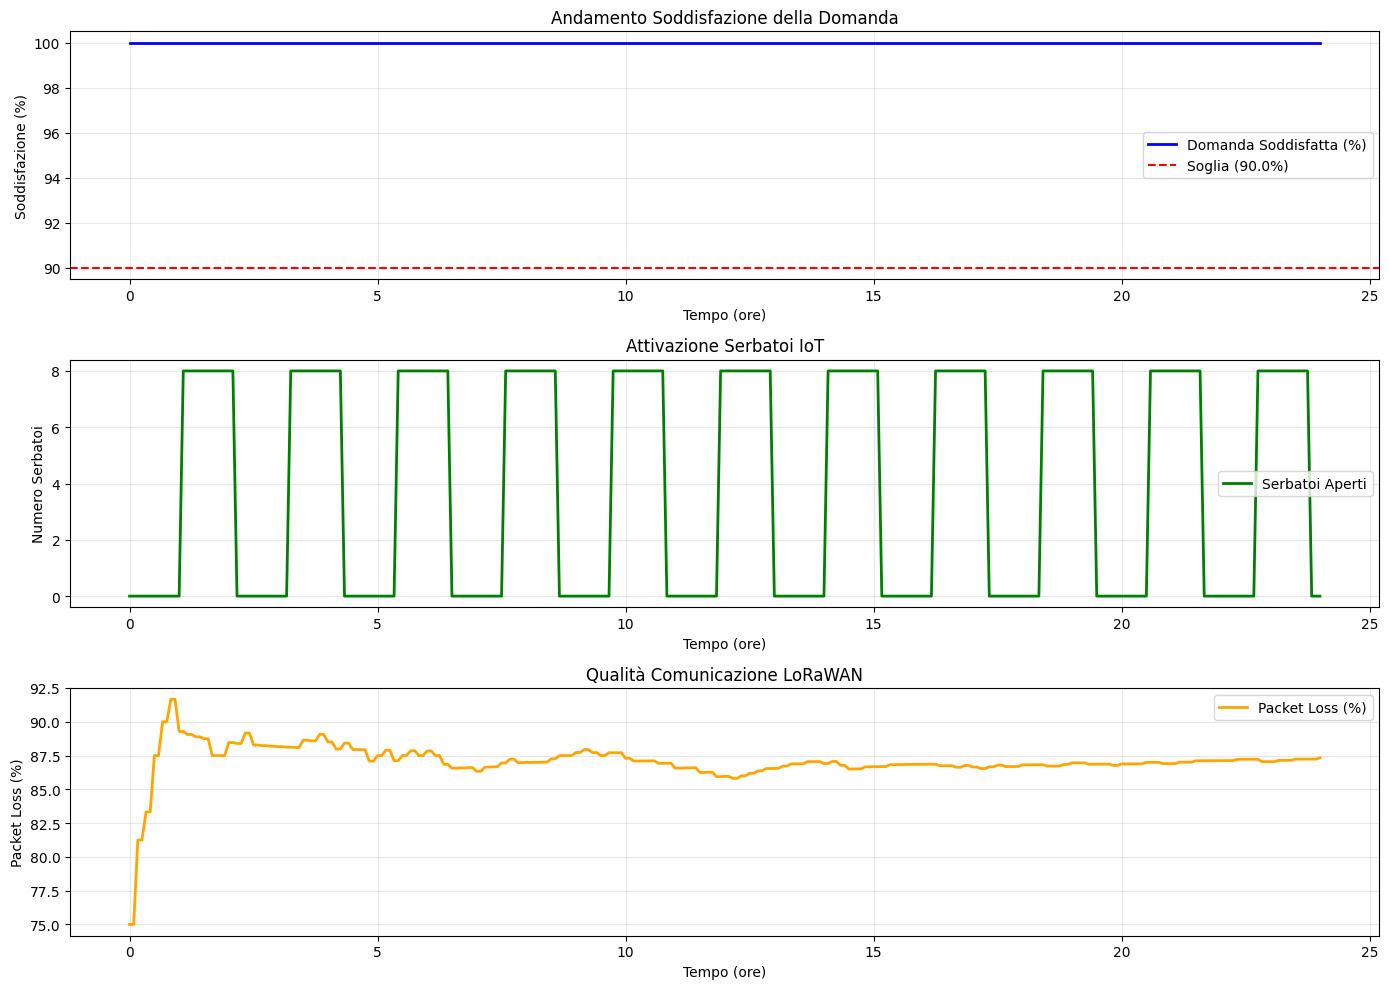

In [ ]:
# Cell opzionale per visualizzazione grafica (richiede matplotlib)
try:
    import matplotlib.pyplot as plt

    # Usa un threshold default esplicito se non esiste più logicamente nello state
    threshold = 95.0

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Grafico 1: Soddisfazione della domanda nel tempo
    axes[0].plot([t/3600 for t in engine.statistics['time']],
                 engine.statistics['demand_satisfaction'],
                 'b-', linewidth=2, label='Domanda Soddisfatta (%)')

    axes[0].axhline(y=threshold, color='r', linestyle='--', label=f'Soglia Comfort ({threshold}%)')
    axes[0].set_xlabel('Tempo (ore)')
    axes[0].set_ylabel('Soddisfazione (%)')
    axes[0].set_title('Andamento Soddisfazione della Domanda (Co-Simulazione)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Grafico 2: Serbatoi aperti nel tempo
    axes[1].plot([t/3600 for t in engine.statistics['time']],
                 engine.statistics['tanks_opened'],
                 'g-', linewidth=2, label='Serbatoi Aperti (Max 3)')
    axes[1].set_xlabel('Tempo (ore)')
    axes[1].set_ylabel('Numero Serbatoi')
    axes[1].set_title('Attivazione Serbatoi IoT (Small, Medium, Large)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Grafico 3: Packet Loss Rate
    axes[2].plot([t/3600 for t in engine.statistics['time']],
                 engine.statistics['packet_loss_rate'],
                 'orange', linewidth=2, label='Packet Loss (%)')
    axes[2].set_xlabel('Tempo (ore)')
    axes[2].set_ylabel('Packet Loss (%)')
    axes[2].set_title('Qualità Comunicazione LoRaWAN (Fisica + ALOHA Collisioni)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('simulation_results.png', dpi=300, bbox_inches='tight')
    print(f"\n📊 Grafici salvati in 'simulation_results.png'")
    plt.show()

except ImportError:
    print("⚠️ Matplotlib non disponibile. Installa con: pip install matplotlib")
except Exception as e:
    print(f"❌ Errore nella generazione del grafico: {e}")